<a href="https://colab.research.google.com/github/indra1236/indra/blob/main/Pengolahan_citra_digital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import cv2

# Matriks sesuai soal (0 dan 1)
matrix = np.array([
[0,0,0,0,0,0,0,0,0,0],
[0,1,1,1,0,0,0,1,1,0],
[0,1,1,1,0,0,0,1,1,0],
[0,1,1,1,0,0,0,0,0,0],
[0,0,0,0,0,0,0,0,0,0],
[0,0,1,1,0,0,1,1,1,0],
[0,0,1,1,0,0,1,1,1,0],
[0,0,0,0,0,0,1,1,1,0],
[0,0,0,0,0,0,0,0,0,0],
[0,0,0,0,0,0,0,0,0,0]
], dtype=np.uint8)

# connectedComponents butuh nilai 0 dan 255
binary = matrix * 255

num_labels, labels = cv2.connectedComponents(binary, connectivity=4)

print("Jumlah objek (4-connectivity):", num_labels - 1)

Jumlah objek (4-connectivity): 4


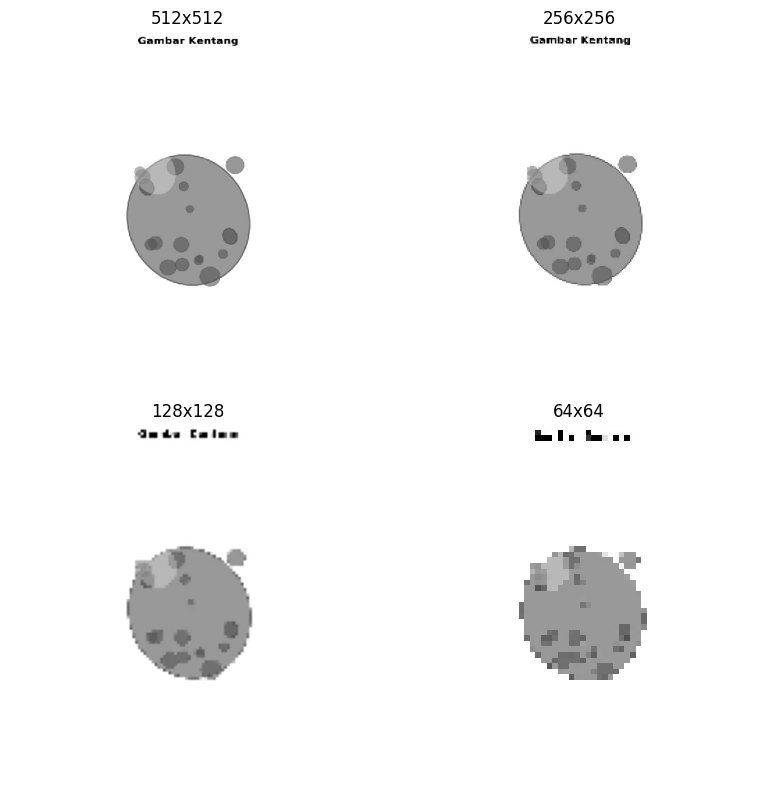

In [7]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/kucing.jpg', cv2.IMREAD_GRAYSCALE)

sizes = [512, 256, 128, 64]

plt.figure(figsize=(8,8))

for i, size in enumerate(sizes):
    resized = cv2.resize(img, (size, size), interpolation=cv2.INTER_NEAREST)

    plt.subplot(2,2,i+1)
    plt.imshow(resized, cmap='gray')
    plt.title(f'{size}x{size}')
    plt.axis('off')

plt.tight_layout()
plt.show()

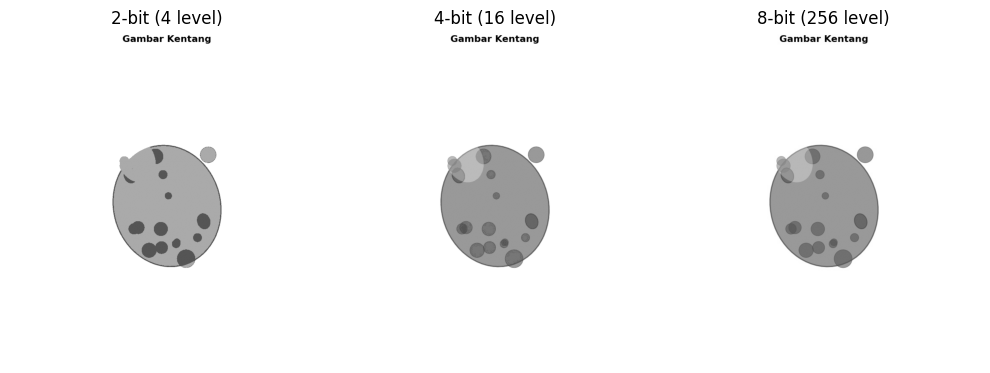

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/kucing.jpg', cv2.IMREAD_GRAYSCALE)

def quantize(image, bits):
    levels = 2**bits
    step = 256 // levels
    return (image // step) * step

q2 = quantize(img, 2)   # 4 level
q4 = quantize(img, 4)   # 16 level
q8 = quantize(img, 8)   # 256 level

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(q2, cmap='gray')
plt.title('2-bit (4 level)')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(q4, cmap='gray')
plt.title('4-bit (16 level)')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(q8, cmap='gray')
plt.title('8-bit (256 level)')
plt.axis('off')

plt.tight_layout()
plt.show()